# Ver.5 Dynamic GLM-HMM — K=2 と K=3 の比較（VG1GC-66）

ノート19は K=3・σ=1 で κ を掃引し、選んだのは κ=∞（`'partial'` そのもの）だった。κ≥100 は κ=∞ と test 対数尤度 −0.001 nats/試行以内で、day 別の遷移行列はこの個体では要らない。

このノートは、その選ばれたモデル族（`'partial'`・σ=1・π 一様・同じ fold）に K=2 を合わせ、K=3 と比べる。K=3 は再学習しない。問いは「ノート19の K=3 解にある3つ目の状態が held-out 尤度を稼いでいるか」で、初期値は K=3 の解から状態を1つ落としたものとする。

| 固定するもの | 値 |
| :--- | :--- |
| 個体・入力 | `VG1GC-66`、修正1後の `[x_bias, x_hist_z, x_rew_z]`、観測 `yA` |
| σ・π・fold | 1、一様固定、ノート18/19と同じ `split_data` |
| 学習 | fold 5回 + 全データ1回の `'partial'`。κ グリッドは回さない |

κ=100 を足すのは、K=2 の test 対数尤度が K=3 を対応差の 1 SE 以上上回り、かつ落とした状態が K=3 全データ解で占有最小の状態ではないときだけ。


## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())


cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
DYN_REPO = Path('external') / 'dynamic_glmhmm'
if not (DYN_REPO / 'code' / 'dynamic_glmhmm.py').exists():
    DYN_REPO.parent.mkdir(parents=True, exist_ok=True)
    os.system(f'git clone --depth 1 https://github.com/lenca56/dynamic_glmhmm {DYN_REPO}')
if str((DYN_REPO / 'code').resolve()) not in sys.path:
    sys.path.insert(0, str((DYN_REPO / 'code').resolve()))

import dynamic_glmhmm
from utils import reshapeSigma, reshapeP_M1_to_M2
from analysis_utils import split_data
print('dynamic_glmhmm:', dynamic_glmhmm.__file__)


dynamic_glmhmm: /mnt/c/Users/dmasu/braidyn-bc/external/dynamic_glmhmm/code/dynamic_glmhmm.py


In [3]:
import time, io as _io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})
from matplotlib import font_manager
for _fp in [Path('/mnt/c/Windows/Fonts/YuGothM.ttc'), Path('/mnt/c/Windows/Fonts/meiryo.ttc'),
            Path('C:/Windows/Fonts/YuGothM.ttc'), Path('C:/Windows/Fonts/meiryo.ttc')]:
    if _fp.exists():
        font_manager.fontManager.addfont(str(_fp))
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(_fp)).get_name()
        break
print('font:', plt.rcParams['font.family'])

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT
ALPHA_REW = v4.ALPHA_REW
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
K3, K2, C = 3, 2, 2
P_THRESHOLD = 0.80
BURN = 20
SIGMA = 1.0
FOLDS, BLOCKS, CV_SEED = 5, 10, 1
PAR_MAXITER, PAR_TOL = 200, 1e-3
PRIOR_DIR_P = [10, 1]
KAPPA_PROBE = 100.0
POS_MEAN_LO, POS_MEAN_HI, POS_SD_MAX = 0.25, 0.75, 0.15
POS_MIN_N = 30
ABSORB_DIAG = 0.999
STATE_COLORS = {2: ['#4c72b0', '#dd8452'], 3: ['#4c72b0', '#dd8452', '#55a868']}

CACHE_DIR = Path('data') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TRIALS = CACHE_DIR / f'ver5_trials_{MOUSE_ID}.pkl'
NB18_CACHE = CACHE_DIR / 'ver5_note18.pkl'
NB19_CACHE = CACHE_DIR / 'ver5_note19.pkl'
NB20_CACHE = CACHE_DIR / 'ver5_note20.pkl'

if CACHE_TRIALS.exists():
    trials_all = pd.read_pickle(CACHE_TRIALS)
    print('キャッシュから読み込み:', CACHE_TRIALS)
else:
    trials_all = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)['trials']
    trials_all.to_pickle(CACHE_TRIALS)

NB18 = pd.read_pickle(NB18_CACHE)
NB19 = pd.read_pickle(NB19_CACHE)
for key in ('final_fixed',):
    if key not in NB18:
        raise RuntimeError(f'ノート18のキャッシュに {key} が無い。先にノート18を実行する。')
if 'partial_folds' not in NB19 or len(NB19['partial_folds']) < FOLDS:
    raise RuntimeError('ノート19の partial_folds が揃っていない。先にノート19を実行する。')
NB20 = pd.read_pickle(NB20_CACHE) if NB20_CACHE.exists() else {}
print('note19 keys:', sorted(NB19))
print('note20 keys:', sorted(NB20) if NB20 else '(なし)')


def save_cache():
    pd.to_pickle(NB20, NB20_CACHE)


@contextlib.contextmanager
def quiet():
    buf = _io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield


環境: ローカル (WSL)


DATA_CSV_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


font: ['Yu Gothic']
キャッシュから読み込み: data/cache/ver5_trials_VG1GC-66.pkl


note19 keys: ['degen', 'dyn_folds', 'eligible', 'kappa_best', 'partial_folds']
note20 keys: ['folds']


## 1. 入力

ノート19と同じ修正1。fold 分割は `N` と `sessInd` だけで決まるのでノート19と同一になる。


In [4]:
def build_sequence(trials_all, h0=0.0, r0=0.0):
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = (g[g['trial_type'].isin(SOUND_TYPES)]
             .sort_values('t_start').reset_index(drop=True).copy())
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        h[0], r[0] = h0, r0
        for k in range(1, n):
            h[k] = a[k - 1] + ALPHA_ACT * h[k - 1]
            r[k] = rw[k - 1] + ALPHA_REW * r[k - 1]
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = 1 - a
        g['k'] = np.arange(n)
        out.append(g)
    tr = pd.concat(out, ignore_index=True)
    for c in ['x_hist', 'x_rew']:
        tr[c + '_z'] = (tr[c] - tr[c].mean()) / tr[c].std(ddof=0)
    return tr


INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']
tr_reset = build_sequence(trials_all)
H0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_hist'].mean())
R0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_rew'].mean())
tr = build_sequence(trials_all, H0, R0)

days = list(dict.fromkeys(tr['task_day'].tolist()))
X = tr[INPUT_COLS].to_numpy(dtype=float)
Y = tr['yA'].to_numpy().astype(int)
SESS = [0] + list(np.cumsum([int((tr['task_day'] == d).sum()) for d in days]))
N, D = X.shape
DAYS = days
DAY_LABELS = [str(d).replace('task-day', 'd') for d in DAYS]

presentTrain, presentTest = split_data(N, SESS, folds=FOLDS, blocks=BLOCKS, random_state=CV_SEED)
print(f'N={N}  D={D}  sessions={len(SESS)-1}  K2={K2}  sigma={SIGMA:g}')
print('day別試行数:', [SESS[i+1] - SESS[i] for i in range(len(SESS)-1)])
print('foldごとのtest試行数:', [int(pt.sum()) for pt in presentTest])


N=2359  D=3  sessions=14  K2=2  sigma=1
day別試行数: [np.int64(76), np.int64(156), np.int64(103), np.int64(183), np.int64(318), np.int64(157), np.int64(153), np.int64(72), np.int64(155), np.int64(233), np.int64(233), np.int64(126), np.int64(231), np.int64(163)]
foldごとのtest試行数: [548, 510, 479, 402, 420]


## 2. K=2 の `'partial'`（σ=1）

各 fold の K=3 `'partial'` から状態を1つ除いた初期値を3通り作る。遷移行列はその行と列を削って行を正規化し、重みはその状態の分を捨てる。3通りの訓練対数尤度は前向き・後ろ向きを1回ずつ回して比べ、EM するのは最良の1通りだけ。π は一様のまま（`fit_init_states=False`）。


In [5]:
def trial_P(P, n):
    A = np.asarray(P, dtype=float)
    if A.ndim == 2:
        A = reshapeP_M1_to_M2(A, n)
    return np.array(A, dtype=float, copy=True)


def contract(P, W, drop):
    '''K=3 のパラメータから状態 drop を除いた K=2 初期値。'''
    keep = [i for i in range(K3) if i != drop]
    A = trial_P(P, N)
    sub = A[:, keep][:, :, keep]
    sub = sub / sub.sum(axis=2, keepdims=True)
    Wc = np.array(W, dtype=float, copy=True)[:, keep]
    pi = np.full(K2, 1.0 / K2)
    return sub, pi, Wc, keep


def score_init(P, pi, W, present):
    present = np.asarray(present).astype(int)
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K2, D, C)
    with quiet():
        _, ll, _ = m.evaluate(X, Y, SESS, present, P, pi, W)
    return float(ll)


def fit_partial(present, P, pi, W):
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K2, D, C)
    with quiet():
        p, pi_hat, w, ll = m.fit(
            X, Y, present, P, pi, W,
            sigma=reshapeSigma(SIGMA, K2, D), sessInd=SESS,
            maxIter=PAR_MAXITER, tol=PAR_TOL, L2penaltyW=0,
            priorDirP=PRIOR_DIR_P, model_type='partial', fit_init_states=False)
    ll = ll[ll != 0]
    present_te = presentTest[int(np.flatnonzero([np.array_equal(present, presentTrain[f]) for f in range(FOLDS)])[0])] \
        if not np.array_equal(present, np.ones(N)) else np.ones(N)
    # 全データフィットは test が無い。fold のときだけ評価する。
    ll_te = np.nan
    if present.sum() < N:
        with quiet():
            _, ll_te, _ = m.evaluate(X, Y, SESS, present_te, p, pi_hat, w)
        ll_te = float(ll_te)
    return dict(p=p, pi=pi_hat, w=w, ll_train=float(ll[-1]), ll_test=ll_te, n_iter=int(len(ll)))


NB20.setdefault('folds', {})
t0 = time.time()
for f in range(FOLDS):
    key = str(f)
    if key in NB20['folds']:
        rec = NB20['folds'][key]
        print(f'[cache] fold {f}: drop {rec["drop"]}  test LL {rec["ll_test"]:+.4f}')
        continue
    src = NB19['partial_folds'][key]
    scores = []
    for drop in range(K3):
        P0, pi0, W0, keep = contract(src['p'], src['w'], drop)
        scores.append(score_init(P0, pi0, W0, presentTrain[f]))
    drop = int(np.nanargmax(scores))
    P0, pi0, W0, keep = contract(src['p'], src['w'], drop)
    print(f'fold {f}: 縮約の訓練LL {np.round(scores, 4)}  → drop state {drop}')
    rec = fit_partial(presentTrain[f], P0, pi0, W0)
    rec.update(drop=drop, keep=keep, init_ll=np.array(scores))
    NB20['folds'][key] = rec
    save_cache()
    print(f'  fold {f}: train {rec["ll_train"]:.1f}  test {rec["ll_test"]:+.4f}'
          f'  iters {rec["n_iter"]}  ({time.time()-t0:.0f}s)')


[cache] fold 0: drop 0  test LL -0.4202
[cache] fold 1: drop 0  test LL -0.4246
[cache] fold 2: drop 1  test LL -0.4312
[cache] fold 3: drop 2  test LL -0.4390
[cache] fold 4: drop 2  test LL -0.3966


## 3. test 対数尤度

K=3 はノート19の `'partial'` σ=1（κ=∞ として選ばれた点）。差は同じ fold の対応で取る。SE はノート19と同じく fold 間標準偏差を √5 で割る（ddof=0）。平均差が −1 SE より悪くなければ、3つ目の状態は held-out 尤度を稼いでいない。


findfont: Failed to find font weight normal, now using 500.


 fold  drop   ll_K2   ll_K3   delta
    0     0 -0.4202 -0.4229  0.0027
    1     0 -0.4246 -0.4245 -0.0000
    2     1 -0.4312 -0.4302 -0.0009
    3     2 -0.4390 -0.4366 -0.0025
    4     2 -0.3966 -0.3971  0.0005
K=2  -0.4223 ± 0.0064
K=3  -0.4223 ± 0.0060
差 K2−K3  -0.0000 ± 0.0008
判定: 3つ目の状態は held-out 尤度を稼いでいない


findfont: Failed to find font weight normal, now using 500.


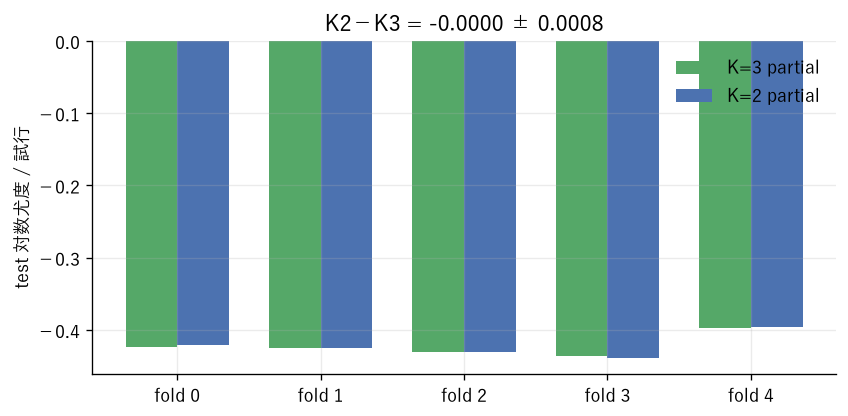

In [6]:
ll2 = np.array([NB20['folds'][str(f)]['ll_test'] for f in range(FOLDS)])
ll3 = np.array([NB19['partial_folds'][str(f)]['ll_test'] for f in range(FOLDS)])
delta = ll2 - ll3
se = float(delta.std(ddof=0) / np.sqrt(FOLDS))
mean_d = float(delta.mean())

rows = pd.DataFrame({
    'fold': range(FOLDS),
    'drop': [NB20['folds'][str(f)]['drop'] for f in range(FOLDS)],
    'll_K2': ll2,
    'll_K3': ll3,
    'delta': delta,
})
print(rows.round(4).to_string(index=False))
print(f'K=2  {ll2.mean():+.4f} ± {ll2.std(ddof=0)/np.sqrt(FOLDS):.4f}')
print(f'K=3  {ll3.mean():+.4f} ± {ll3.std(ddof=0)/np.sqrt(FOLDS):.4f}')
print(f'差 K2−K3  {mean_d:+.4f} ± {se:.4f}')
k2_not_worse = mean_d >= -se
print('判定: 3つ目の状態は held-out 尤度を稼いでいない' if k2_not_worse
      else '判定: K=2 は K=3 より 1 SE を超えて悪い')

fig, ax = plt.subplots(figsize=(7.2, 3.6))
x = np.arange(FOLDS)
ax.bar(x - 0.18, ll3, width=0.36, color='#55a868', label='K=3 partial')
ax.bar(x + 0.18, ll2, width=0.36, color='#4c72b0', label='K=2 partial')
ax.set_xticks(x)
ax.set_xticklabels([f'fold {f}' for f in range(FOLDS)])
ax.set_ylabel('test 対数尤度 / 試行')
ax.set_title(f'K2−K3 = {mean_d:+.4f} ± {se:.4f}')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. 全データでの K=2

初期値はノート18の全データ `'partial'`（ノート19が κ=∞ の最終解に使ったもの）から、同じ縮約で作る。落とす状態は、3通りの全データ対数尤度（前向き1回）が最大のもの。


In [7]:
p3, pi3, w3 = NB18['final_fixed']['par']

if 'final' in NB20:
    rec = NB20['final']
    print(f'[cache] 全データ: drop {rec["drop"]}  train LL {rec["ll_train"]:.1f}')
else:
    scores = []
    for drop in range(K3):
        P0, pi0, W0, keep = contract(p3, w3, drop)
        scores.append(score_init(P0, pi0, W0, np.ones(N)))
    drop = int(np.nanargmax(scores))
    P0, pi0, W0, keep = contract(p3, w3, drop)
    print(f'全データ: 縮約のLL {np.round(scores, 4)}  → drop state {drop}')
    t0 = time.time()
    rec = fit_partial(np.ones(N), P0, pi0, W0)
    rec.update(drop=drop, keep=keep, init_ll=np.array(scores))
    NB20['final'] = rec
    save_cache()
    print(f'  train {rec["ll_train"]:.1f}  iters {rec["n_iter"]}  ({time.time()-t0:.0f}s)')

final2 = NB20['final']


全データ: 縮約のLL [-0.4109 -0.4112 -0.4039]  → drop state 2


  train -945.0  iters 13  (11s)


## 5. 状態構造

K=3 はノート18の全データ `'partial'` を前向き・後ろ向きするだけで、学習はしない。上段は day を揃えた MAP 状態、下段は占有率。


[K=3 partial]
  1状態が90%以上のday: 6/14  (最頻状態占有率の中央値 0.761)
  day内の状態切り替え: 合計 29 回 / day中央値 1  / day別 [4, 1, 0, 1, 1, 0, 3, 1, 1, 2, 6, 0, 6, 3]
  state run長: 中央値 32 試行 / 最大 245
  p_max 平均 0.714 / P(z)>=0.8 残存率 0.351
  day内の正規化位置（状態別 平均±sd）:
    state 0: n= 453  pos 0.506 ± 0.314
    state 1: n=1803  pos 0.486 ± 0.279
    state 2: n= 103  pos 0.652 ± 0.297
  |W| の最大 2.67
  吸収対角の day: 0  時計化した状態: —



[K=2 partial]
  1状態が90%以上のday: 6/14  (最頻状態占有率の中央値 0.830)
  day内の状態切り替え: 合計 18 回 / day中央値 1  / day別 [1, 3, 0, 1, 1, 0, 2, 0, 1, 1, 4, 0, 2, 2]
  state run長: 中央値 47 試行 / 最大 247
  p_max 平均 0.827 / P(z)>=0.8 残存率 0.576
  day内の正規化位置（状態別 平均±sd）:
    state 0: n= 487  pos 0.516 ± 0.328
    state 1: n=1872  pos 0.492 ± 0.277
  |W| の最大 2.63
  吸収対角の day: 0  時計化した状態: —

K=3 で占有が最小の状態: 2  (n=103)
全データの K=2 が落とした状態: 2  残した状態: [0, 1]


findfont: Failed to find font weight normal, now using 500.


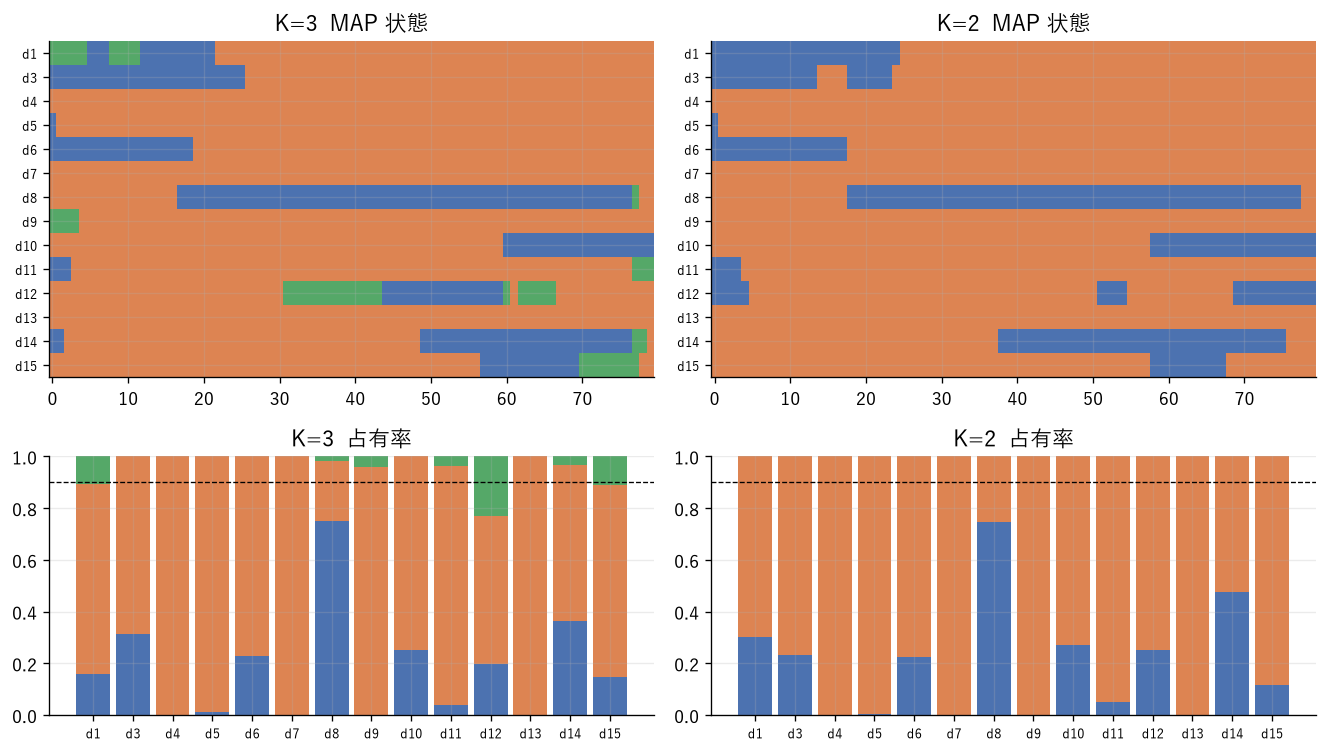

In [8]:
def decode_params(P, pi, W, K):
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    Pt = trial_P(P, N)
    with quiet():
        gamma = m.posterior_likelihood_of_each_state(Pt, pi, W, X, Y, np.ones(N), SESS)
    return gamma, gamma.argmax(axis=1), gamma.max(axis=1)


def state_summary(P, pi, W, K, label):
    gamma, z, pmax = decode_params(P, pi, W, K)
    occ = np.zeros((len(DAYS), K))
    switches, runs = [], []
    pos_by_state = [[] for _ in range(K)]
    for i in range(len(DAYS)):
        sl = slice(SESS[i], SESS[i + 1])
        zi = z[sl]
        for k in range(K):
            occ[i, k] = (zi == k).mean()
        switches.append(int((np.diff(zi) != 0).sum()))
        cut = np.flatnonzero(np.diff(zi) != 0) + 1
        runs += [len(s) for s in np.split(zi, cut)]
        rel = np.linspace(0, 1, len(zi), endpoint=False)
        for k in range(K):
            pos_by_state[k].append(rel[zi == k])
    dom = occ.max(axis=1)
    Pt = trial_P(P, N)
    absorb_days = int(sum(np.any(np.diag(Pt[SESS[s]]) >= ABSORB_DIAG) for s in range(len(DAYS))))
    clock = []
    print(f'[{label}]')
    print(f'  1状態が90%以上のday: {int((dom >= 0.9).sum())}/{len(DAYS)}'
          f'  (最頻状態占有率の中央値 {np.median(dom):.3f})')
    print(f'  day内の状態切り替え: 合計 {sum(switches)} 回 / day中央値 {int(np.median(switches))}'
          f'  / day別 {switches}')
    print(f'  state run長: 中央値 {int(np.median(runs))} 試行 / 最大 {max(runs)}')
    print(f'  p_max 平均 {pmax.mean():.3f} / P(z)>={P_THRESHOLD} 残存率 {(pmax >= P_THRESHOLD).mean():.3f}')
    print('  day内の正規化位置（状態別 平均±sd）:')
    for k in range(K):
        v = np.concatenate(pos_by_state[k]) if pos_by_state[k] else np.array([])
        if v.size == 0:
            desc = 'n/a'
        else:
            desc = f'{v.mean():.3f} ± {v.std():.3f}'
            if v.size >= POS_MIN_N and (v.mean() < POS_MEAN_LO or v.mean() > POS_MEAN_HI) and v.std() < POS_SD_MAX:
                clock.append(k)
        print(f'    state {k}: n={int((z == k).sum()):4d}  pos {desc}')
    print(f'  |W| の最大 {np.abs(W[:, :, :, 1]).max():.2f}')
    print(f'  吸収対角の day: {absorb_days}  時計化した状態: {clock or "—"}')
    print()
    return dict(gamma=gamma, z=z, pmax=pmax, occ=occ, switches=np.array(switches), dom=dom)


sm3 = state_summary(p3, np.full(K3, 1.0 / K3), w3, K3, 'K=3 partial')
sm2 = state_summary(final2['p'], final2['pi'], final2['w'], K2, 'K=2 partial')
rare3 = int(np.bincount(sm3['z'], minlength=K3).argmin())
print(f'K=3 で占有が最小の状態: {rare3}  (n={int((sm3["z"] == rare3).sum())})')
print(f'全データの K=2 が落とした状態: {final2["drop"]}  残した状態: {final2["keep"]}')

BINS = 80

def raster_of(z, K):
    raster = np.full((len(DAYS), BINS), np.nan)
    for i in range(len(DAYS)):
        zi = z[SESS[i]:SESS[i + 1]]
        for b in range(BINS):
            a = int(b / BINS * len(zi))
            c = int((b + 1) / BINS * len(zi))
            chunk = zi[a:max(c, a + 1)]
            raster[i, b] = np.bincount(chunk, minlength=K).argmax()
    return raster


fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.4), gridspec_kw={'height_ratios': [1.3, 1]})
for col, (sm, K, title) in enumerate(((sm3, K3, 'K=3'), (sm2, K2, 'K=2'))):
    ax = axes[0, col]
    cmap = plt.matplotlib.colors.ListedColormap(STATE_COLORS[K])
    ax.imshow(raster_of(sm['z'], K), aspect='auto', cmap=cmap, vmin=-0.5, vmax=K - 0.5, interpolation='nearest')
    ax.set_yticks(range(len(DAYS)))
    ax.set_yticklabels(DAY_LABELS, fontsize=8)
    ax.set_title(f'{title}  MAP 状態')
    ax = axes[1, col]
    bottom = np.zeros(len(DAYS))
    for k in range(K):
        ax.bar(np.arange(len(DAYS)), sm['occ'][:, k], bottom=bottom, color=STATE_COLORS[K][k], width=0.85)
        bottom += sm['occ'][:, k]
    ax.axhline(0.9, color='black', lw=0.8, ls='--')
    ax.set_xticks(range(len(DAYS)))
    ax.set_xticklabels(DAY_LABELS, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title}  占有率')
fig.tight_layout()
plt.show()


## 6. 皮質デコードに使える試行数

ノート19と同じ手続き。`P(z)≥0.8` で離散状態に割り当て、day 内で状態×試行タイプの最小セルに合わせて数える。尤度が並んだときの採否は、この試行数で見る。


K=3
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      17         0                0
 task-day3    156      35         0                0
 task-day4    103       0         0                0
 task-day5    183       0         0                0
 task-day6    318     169         0                0
 task-day7    157      95         0                0
 task-day8    153      83         0                0
 task-day9     72       0         0                0
task-day10    155      79         0                0
task-day11    233      24         0                0
task-day12    233     110         3               36
task-day13    126      49         0                0
task-day14    231      53         0                0
task-day15    163     113         0                0
balanced 使用可能試行: 36 / min_cell=0 の day 13/14
K=2
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      57         0               28
 task-day3    156      55         0           

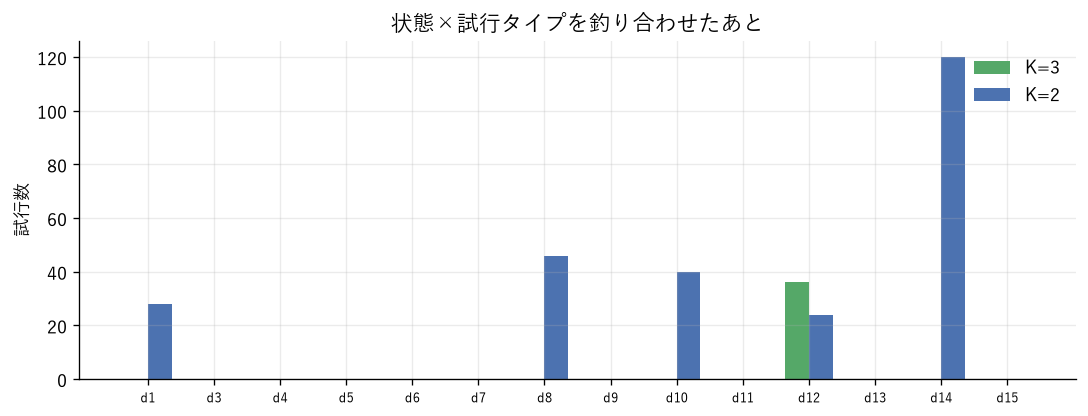

In [9]:
def balancing_table(sm, K):
    t2 = tr.copy()
    t2['state'] = sm['z']
    t2['p_max'] = sm['pmax']
    kept = t2[t2['p_max'] >= P_THRESHOLD]
    rows = []
    for d in DAYS:
        g = kept[kept['task_day'] == d]
        ct = pd.crosstab(g['trial_type'], g['state'])
        ct = ct.reindex(index=SOUND_TYPES, columns=range(K), fill_value=0)
        rows.append({
            'task_day': d,
            'n_all': int((t2['task_day'] == d).sum()),
            'n_kept': len(g),
            'min_cell': int(ct.values.min()) if ct.size else 0,
            'usable_balanced': int((ct.min(axis=1) * K).sum()) if len(g) else 0,
        })
    return pd.DataFrame(rows)


bal3 = balancing_table(sm3, K3)
bal2 = balancing_table(sm2, K2)
print('K=3')
print(bal3.to_string(index=False))
print(f'balanced 使用可能試行: {int(bal3["usable_balanced"].sum())} / '
      f'min_cell=0 の day {int((bal3["min_cell"] == 0).sum())}/{len(bal3)}')
print('K=2')
print(bal2.to_string(index=False))
print(f'balanced 使用可能試行: {int(bal2["usable_balanced"].sum())} / '
      f'min_cell=0 の day {int((bal2["min_cell"] == 0).sum())}/{len(bal2)}')

fig, ax = plt.subplots(figsize=(9.2, 3.6))
x = np.arange(len(DAYS))
ax.bar(x - 0.18, bal3['usable_balanced'], width=0.36, color='#55a868', label='K=3')
ax.bar(x + 0.18, bal2['usable_balanced'], width=0.36, color='#4c72b0', label='K=2')
ax.set_xticks(x)
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylabel('試行数')
ax.set_title('状態×試行タイプを釣り合わせたあと')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 7. κ=100 を足すか

K=2 の test 対数尤度が K=3 を対応差の 1 SE 以上上回り、かつ fold で最も多く落とした状態が、K=3 全データ解の占有最小状態ではないときだけ、κ=100 を 5 fold 学習する。それ以外は κ を回さない。


In [10]:
drops = [NB20['folds'][str(f)]['drop'] for f in range(FOLDS)]
modal_drop = max(set(drops), key=drops.count)
need_kappa = (mean_d > se) and (modal_drop != rare3)
print(f'fold が落とした状態: {drops}  最頻 {modal_drop}  占有最小 {rare3}')
print(f'κ=100 を学習する: {need_kappa}')

def as_global_P(P):
    A = trial_P(P, N)[0]
    return A / A.sum(axis=1, keepdims=True)


def fit_kappa100(present, P, pi, W):
    A = as_global_P(P)
    initP = reshapeP_M1_to_M2(A, N)
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K2, D, C)
    with quiet():
        p, pi_hat, w, ll = m.fit(
            X, Y, present, initP, pi, W,
            sigma=reshapeSigma(SIGMA, K2, D), alpha=KAPPA_PROBE, A=A, sessInd=SESS,
            maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='dynamic',
            L2penaltyW=0, priorDirP=None, fit_init_states=False)
    ll = ll[ll != 0]
    f = int(np.flatnonzero([np.array_equal(present, presentTrain[i]) for i in range(FOLDS)])[0])
    with quiet():
        _, ll_te, _ = m.evaluate(X, Y, SESS, presentTest[f], p, pi_hat, w)
    return dict(p=p, pi=pi_hat, w=w, ll_train=float(ll[-1]), ll_test=float(ll_te), n_iter=int(len(ll)))


if not need_kappa:
    print('κ=100 は学習しない。比較は partial の6フィットで閉じる。')
else:
    NB20.setdefault('kappa100', {})
    t0 = time.time()
    for f in range(FOLDS):
        key = str(f)
        if key in NB20['kappa100']:
            print(f'[cache] κ=100 fold {f}: test LL {NB20["kappa100"][key]["ll_test"]:+.4f}')
            continue
        src = NB20['folds'][key]
        print(f'κ=100 fold {f} を学習...')
        rec = fit_kappa100(presentTrain[f], src['p'], src['pi'], src['w'])
        NB20['kappa100'][key] = rec
        save_cache()
        print(f'  test {rec["ll_test"]:+.4f}  iters {rec["n_iter"]}  ({time.time()-t0:.0f}s)')
    llk = np.array([NB20['kappa100'][str(f)]['ll_test'] for f in range(FOLDS)])
    dk = llk - ll2
    print(f'κ=100  {llk.mean():+.4f}  対 partial {dk.mean():+.4f} ± {dk.std(ddof=0)/np.sqrt(FOLDS):.4f}')


fold が落とした状態: [0, 0, 1, 2, 2]  最頻 0  占有最小 2
κ=100 を学習する: False
κ=100 は学習しない。比較は partial の6フィットで閉じる。


## 8. 読み方

In [11]:
n_fit = FOLDS + 1 + (FOLDS if need_kappa else 0)
print('=' * 72)
print(f'学習したフィット: {n_fit}  （partial {FOLDS}+1'
      + (f'、κ=100 {FOLDS}' if need_kappa else '') + '）')
print(f'K=2 {ll2.mean():+.4f}   K=3 {ll3.mean():+.4f}   差 {mean_d:+.4f} ± {se:.4f}')
print(f'1状態≥90% の day:  K=3 {int((sm3["dom"] >= 0.9).sum())}/14   K=2 {int((sm2["dom"] >= 0.9).sum())}/14')
print(f'切り替え合計:  K=3 {int(sm3["switches"].sum())}   K=2 {int(sm2["switches"].sum())}')
print(f'P(z)≥{P_THRESHOLD}:  K=3 {(sm3["pmax"] >= P_THRESHOLD).mean():.3f}   K=2 {(sm2["pmax"] >= P_THRESHOLD).mean():.3f}')
print(f'balanced 試行:  K=3 {int(bal3["usable_balanced"].sum())}   K=2 {int(bal2["usable_balanced"].sum())}')
print('=' * 72)


学習したフィット: 6  （partial 5+1）
K=2 -0.4223   K=3 -0.4223   差 -0.0000 ± 0.0008
1状態≥90% の day:  K=3 6/14   K=2 6/14
切り替え合計:  K=3 29   K=2 18
P(z)≥0.8:  K=3 0.351   K=2 0.576
balanced 試行:  K=3 36   K=2 258
